In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import time
from time import perf_counter




# Load cleaned dataset for model training


In [2]:

df = pd.read_parquet("cleaned_student_mental_health.parquet")

# Separate features and target
X = df.drop(columns=["Depression"])
y = df["Depression"]

print(df.shape)
df.head()


(27875, 44)


,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,...,City_Patna,City_Pune,City_Rajkot,City_Srinagar,City_Surat,City_Thane,City_Vadodara,City_Varanasi,City_Vasai-Virar,City_Visakhapatnam
0,33.0,5,8.97,2,1,1,1,1,3.0,1,...,0,0,0,0,0,0,0,0,0,1
1,24.0,2,5.90,5,1,0,1,0,3.0,2,...,0,0,0,0,0,0,0,0,0,0
2,31.0,3,7.03,5,0,1,1,0,9.0,1,...,0,0,0,1,0,0,0,0,0,0
3,28.0,3,5.59,2,2,0,1,1,4.0,5,...,0,0,0,0,0,0,0,1,0,0
4,25.0,4,8.13,3,1,0,2,1,1.0,1,...,0,0,0,0,0,0,0,0,0,0


## Split + Scale
- Split data into train and test (stratified)
- Fit scaler only on training data (prevents leakage)
- Scale only: Age, CGPA, Work/Study Hours


In [3]:
# Split X and y
X = df.drop(columns=["Depression"]).copy()
y = df["Depression"].copy()

# Train/Test split (stratify keeps same class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale only continuous columns
scale_cols = ["Age", "CGPA", "Work/Study Hours"]
scaler = StandardScaler()

# Fit ONLY on train, then transform train & test
X_train.loc[:, scale_cols] = scaler.fit_transform(X_train[scale_cols]).astype("float32")
X_test.loc[:, scale_cols]  = scaler.transform(X_test[scale_cols]).astype("float32")

# Quick check
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain scaled stats:\n", X_train[scale_cols].describe())
print("\nTest scaled stats:\n", X_test[scale_cols].describe())


Train shape: (22300, 43) | Test shape: (5575, 43)

Train scaled stats:
                 Age          CGPA  Work/Study Hours
count  2.230000e+04  2.230000e+04      2.230000e+04
mean  -2.052752e-09  1.026376e-08     -6.842507e-10
std    1.000022e+00  1.000022e+00      1.000022e+00
min   -1.600165e+00 -5.206918e+00     -1.926776e+00
25%   -9.879550e-01 -9.322161e-01     -8.497983e-01
50%    3.239497e-02  7.359602e-02      2.271795e-01
75%    8.486750e-01  8.619355e-01      7.656685e-01
max    6.562635e+00  1.589110e+00      1.304157e+00

Test scaled stats:
                Age         CGPA  Work/Study Hours
count  5575.000000  5575.000000       5575.000000
mean     -0.019620    -0.019803          0.001497
std       1.005832     0.998061          0.991284
min      -1.600165    -5.206918         -1.926776
25%      -0.987955    -0.945808         -0.849798
50%      -0.171675     0.053208          0.227180
75%       0.848675     0.848343          0.765669
max       6.766705     1.589110        

In [4]:
print("Any NaNs in train:", X_train.isna().sum().sum())
print("Any NaNs in test:", X_test.isna().sum().sum())


Any NaNs in train: 0
Any NaNs in test: 0


In [5]:
X_train.head()

,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,...,City_Patna,City_Pune,City_Rajkot,City_Srinagar,City_Surat,City_Thane,City_Vadodara,City_Varanasi,City_Vasai-Virar,City_Visakhapatnam
12370,1.256815,4,0.630870,2,0,-1,3,0,-0.580554,5,...,0,0,0,0,0,0,0,0,0,0
12004,-0.987955,3,1.337657,3,2,0,2,0,0.496424,4,...,0,0,0,0,0,0,0,0,0,0
24056,-1.396095,2,-1.217649,3,1,0,0,1,-0.042065,3,...,0,0,0,0,0,1,0,0,0,0
15038,0.644605,5,0.467766,2,0,1,2,1,0.765669,5,...,0,0,0,0,0,0,0,0,0,0
17954,0.440535,5,0.732811,2,0,1,1,1,-0.580554,2,...,0,0,0,0,0,0,0,0,1,0


## Verify stratified sampling
- Check class distribution in full data, train set, and test set
- Proportions should be nearly the same


In [6]:
# Class distribution check (counts + proportions)

print("Full dataset distribution:")
display(
    y.value_counts().to_frame("count")
     .assign(proportion=lambda x: (x["count"] / x["count"].sum()).round(3))
)

print("\nTrain set distribution:")
display(
    y_train.value_counts().to_frame("count")
     .assign(proportion=lambda x: (x["count"] / x["count"].sum()).round(3))
)

print("\nTest set distribution:")
display(
    y_test.value_counts().to_frame("count")
     .assign(proportion=lambda x: (x["count"] / x["count"].sum()).round(3))
)


Full dataset distribution:


,count,proportion
Depression,,
1,16321,0.586
0,11554,0.414



Train set distribution:


,count,proportion
Depression,,
1,13057,0.586
0,9243,0.414



Test set distribution:


,count,proportion
Depression,,
1,3264,0.585
0,2311,0.415


In [7]:
# Train Logistic Regression baseline
lr_model = LogisticRegression(solver="liblinear", random_state=42)

start = perf_counter()
lr_model.fit(X_train, y_train)
lr_train_time = round(perf_counter() - start, 3)

lr_train_time


0.046

In [8]:
log_reg = LogisticRegression(random_state=42, max_iter=1000, solver="lbfgs")

start = time.time()
log_reg.fit(X_train, y_train)
end = time.time()

print("Model trained successfully!")
print("Training time:", round(end - start, 4), "seconds")
print("\nModel parameters:\n", log_reg.get_params())

Model trained successfully!
Training time: 0.1169 seconds

Model parameters:
 {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [9]:
# Predictions and probabilities
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics rounded to 3 decimals
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy_score(y_test, y_pred_lr), 3),
    "Precision": round(precision_score(y_test, y_pred_lr), 3),
    "Recall": round(recall_score(y_test, y_pred_lr), 3),
    "F1": round(f1_score(y_test, y_pred_lr), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_lr), 3),
    "Training Time (s)": lr_train_time
}

lr_results_df = pd.DataFrame([lr_metrics])
lr_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.848,0.859,0.886,0.873,0.922,0.046


In [10]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Extract values
tn, fp, fn, tp = cm_lr.ravel()

# Confusion Matrix table
cm_lr_df = pd.DataFrame(
    cm_lr,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_lr_df


,Predicted 0,Predicted 1
Actual 0,1837,474
Actual 1,371,2893


In [11]:
# TP / FP / TN / FN breakdown table
error_breakdown_df = pd.DataFrame({
    "Metric": ["True Positives (TP)", "False Positives (FP)", 
               "True Negatives (TN)", "False Negatives (FN)"],
    "Count": [tp, fp, tn, fn]
})

error_breakdown_df


,Metric,Count
0,True Positives (TP),2893
1,False Positives (FP),474
2,True Negatives (TN),1837
3,False Negatives (FN),371


In [12]:
# Classification report 
report_lr = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

report_lr_df = pd.DataFrame(report_lr).T.round(3)
report_lr_df


,precision,recall,f1-score,support
0,0.832,0.795,0.813,2311.000
1,0.859,0.886,0.873,3264.000
accuracy,0.848,0.848,0.848,0.848
macro avg,0.846,0.841,0.843,5575.000
weighted avg,0.848,0.848,0.848,5575.000


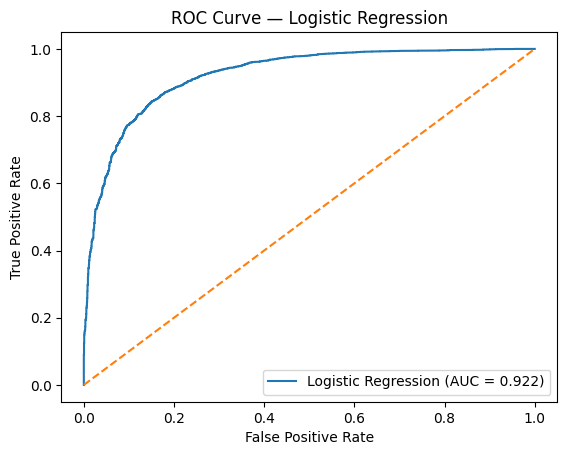

In [13]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = round(auc(fpr_lr, tpr_lr), 3)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


In [14]:
# Train baseline Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)

start = perf_counter()
dt_base.fit(X_train, y_train)
dt_train_time = round(perf_counter() - start, 3)

dt_train_time


0.101

In [15]:
# Predictions and probabilities
y_pred_dt = dt_base.predict(X_test)
y_proba_dt = dt_base.predict_proba(X_test)[:, 1]

dt_metrics = {
    "Model": "Decision Tree (Baseline)",
    "Accuracy": round(accuracy_score(y_test, y_pred_dt), 3),
    "Precision": round(precision_score(y_test, y_pred_dt), 3),
    "Recall": round(recall_score(y_test, y_pred_dt), 3),
    "F1": round(f1_score(y_test, y_pred_dt), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_dt), 3),
    "Training Time (s)": dt_train_time
}

dt_base_results_df = pd.DataFrame([dt_metrics])
dt_base_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Decision Tree (Baseline),0.776,0.809,0.807,0.808,0.769,0.101


In [16]:
# Hyperparameter grid
depth_values = [2, 3, 5, 7, 10, None]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc"
    )
    dt_cv_results.append({
        "max_depth": str(depth),
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

dt_cv_df = pd.DataFrame(dt_cv_results)
dt_cv_df


,max_depth,Mean ROC-AUC,Std ROC-AUC
0,2,0.840,0.005
1,3,0.873,0.002
2,5,0.895,0.002
3,7,0.900,0.002
4,10,0.857,0.003
5,None,0.770,0.007


In [17]:
# Select best depth
best_depth = dt_cv_df.loc[
    dt_cv_df["Mean ROC-AUC"].idxmax(), "max_depth"
]
best_depth = None if best_depth == "None" else int(best_depth)

# Train final model
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

start = perf_counter()
dt_final.fit(X_train, y_train)
dt_final_train_time = round(perf_counter() - start, 3)

best_depth, dt_final_train_time


(7, 0.047)

In [18]:
# Predictions and probabilities
y_pred_dt_final = dt_final.predict(X_test)
y_proba_dt_final = dt_final.predict_proba(X_test)[:, 1]

dt_final_metrics = {
    "Model": "Decision Tree",
    "Accuracy": round(accuracy_score(y_test, y_pred_dt_final), 3),
    "Precision": round(precision_score(y_test, y_pred_dt_final), 3),
    "Recall": round(recall_score(y_test, y_pred_dt_final), 3),
    "F1": round(f1_score(y_test, y_pred_dt_final), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_dt_final), 3),
    "Training Time (s)": dt_final_train_time
}

dt_final_results_df = pd.DataFrame([dt_final_metrics])
dt_final_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Decision Tree,0.833,0.836,0.888,0.861,0.901,0.047


In [19]:
# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt_final)
tn, fp, fn, tp = cm_dt.ravel()

# Confusion matrix table
cm_dt_df = pd.DataFrame(
    cm_dt,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

# TP / FP / TN / FN breakdown table
error_dt_df = pd.DataFrame({
    "Metric": [
        "True Positives (TP)",
        "False Positives (FP)",
        "True Negatives (TN)",
        "False Negatives (FN)"
    ],
    "Count": [tp, fp, tn, fn]
})

# Display tables only (no raw output text)
display(cm_dt_df)
display(error_dt_df)


,Predicted 0,Predicted 1
Actual 0,1744,567
Actual 1,366,2898


,Metric,Count
0,True Positives (TP),2898
1,False Positives (FP),567
2,True Negatives (TN),1744
3,False Negatives (FN),366


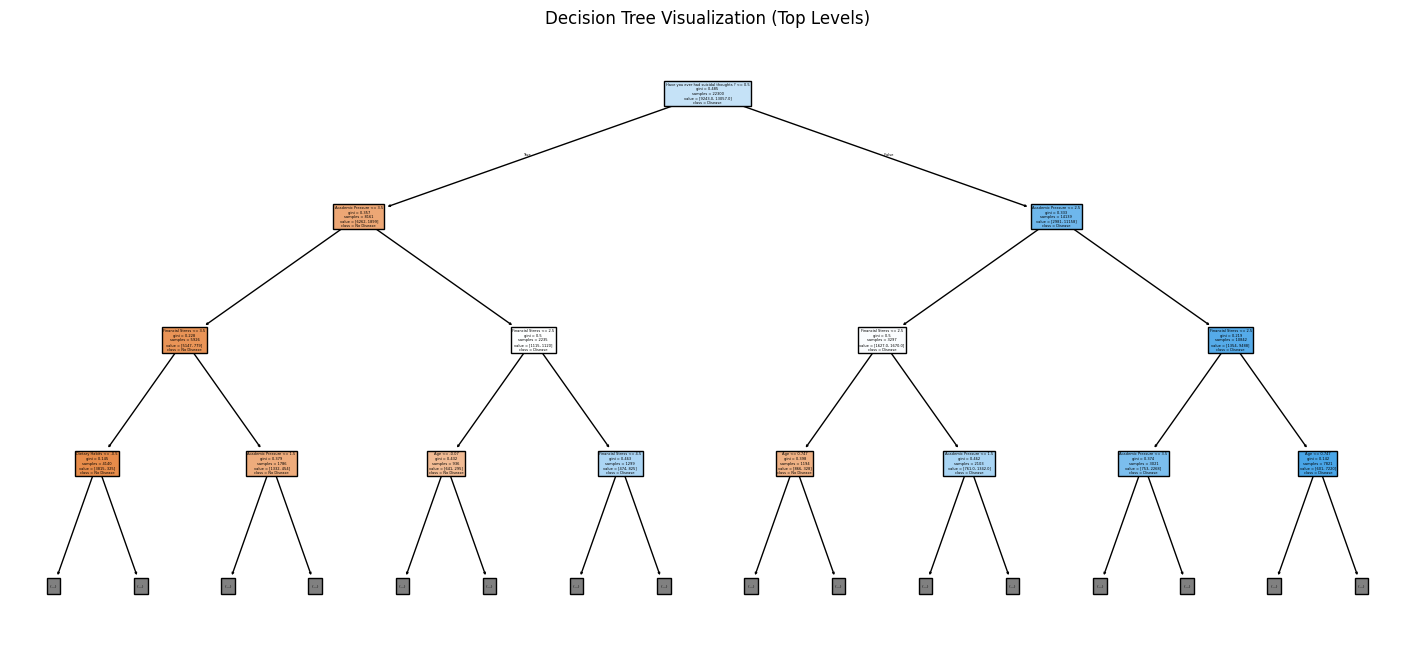

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = X_train.columns.tolist()

plt.figure(figsize=(18, 8))
plot_tree(
    dt_final,
    feature_names=feature_names,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Visualization (Top Levels)")
plt.show()


In [21]:
rf_base = RandomForestClassifier(random_state=42)

start = perf_counter()
rf_base.fit(X_train, y_train)
rf_base_train_time = round(perf_counter() - start, 3)

rf_base_train_time


1.626

In [22]:
y_pred_rf_base = rf_base.predict(X_test)
y_proba_rf_base = rf_base.predict_proba(X_test)[:, 1]

rf_base_metrics = {
    "Model": "Random Forest (Baseline)",
    "Accuracy": round(accuracy_score(y_test, y_pred_rf_base), 3),
    "Precision": round(precision_score(y_test, y_pred_rf_base), 3),
    "Recall": round(recall_score(y_test, y_pred_rf_base), 3),
    "F1": round(f1_score(y_test, y_pred_rf_base), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_rf_base), 3),
    "Training Time (s)": rf_base_train_time
}

rf_base_results_df = pd.DataFrame([rf_base_metrics])
rf_base_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest (Baseline),0.844,0.857,0.881,0.869,0.917,1.626


In [23]:
n_values = [50, 100, 200, 300]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_n_results = []

for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
    rf_n_results.append({
        "n_estimators": n,
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

rf_n_df = pd.DataFrame(rf_n_results)
rf_n_df


,n_estimators,Mean ROC-AUC,Std ROC-AUC
0,50,0.912,0.002
1,100,0.915,0.002
2,200,0.916,0.002
3,300,0.916,0.002


In [24]:
best_n = rf_n_df.loc[rf_n_df["Mean ROC-AUC"].idxmax(), "n_estimators"]
depth_values = [5, 10, 15, None]

rf_depth_results = []

for depth in depth_values:
    rf = RandomForestClassifier(
        n_estimators=best_n,
        max_depth=depth,
        random_state=42
    )
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
    rf_depth_results.append({
        "max_depth": str(depth),
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

rf_depth_df = pd.DataFrame(rf_depth_results)
rf_depth_df


,max_depth,Mean ROC-AUC,Std ROC-AUC
0,5,0.911,0.002
1,10,0.917,0.002
2,15,0.917,0.002
3,None,0.916,0.002


In [25]:
best_depth = rf_depth_df.loc[
    rf_depth_df["Mean ROC-AUC"].idxmax(), "max_depth"
]
best_depth = None if best_depth == "None" else int(best_depth)

rf_best = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42
)

start = perf_counter()
rf_best.fit(X_train, y_train)
rf_train_time = round(perf_counter() - start, 3)

best_n, best_depth, rf_train_time


(np.int64(200), 10, 1.705)

In [26]:
y_pred_rf = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": round(accuracy_score(y_test, y_pred_rf), 3),
    "Precision": round(precision_score(y_test, y_pred_rf), 3),
    "Recall": round(recall_score(y_test, y_pred_rf), 3),
    "F1": round(f1_score(y_test, y_pred_rf), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_rf), 3),
    "Training Time (s)": rf_train_time
}

rf_results_df = pd.DataFrame([rf_metrics])
rf_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.844,0.846,0.897,0.871,0.919,1.705


In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

error_rf_df = pd.DataFrame({
    "Metric": [
        "True Positives (TP)",
        "False Positives (FP)",
        "True Negatives (TN)",
        "False Negatives (FN)"
    ],
    "Count": [tp, fp, tn, fn]
})

display(cm_rf_df)
display(error_rf_df)


,Predicted 0,Predicted 1
Actual 0,1779,532
Actual 1,337,2927


,Metric,Count
0,True Positives (TP),2927
1,False Positives (FP),532
2,True Negatives (TN),1779
3,False Negatives (FN),337


In [28]:
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

feature_importance_df = pd.DataFrame({
    "Feature": [feature_names[i] for i in indices],
    "Importance": np.round(importances[indices], 3)
})

feature_importance_df.head(10)


,Feature,Importance
0,Have you ever had suicidal thoughts ?,0.353
1,Academic Pressure,0.243
2,Financial Stress,0.128
3,Age,0.064
4,Work/Study Hours,0.047
5,Dietary Habits,0.037
6,Study Satisfaction,0.028
7,CGPA,0.023
8,Degree,0.016
9,Sleep Duration,0.013


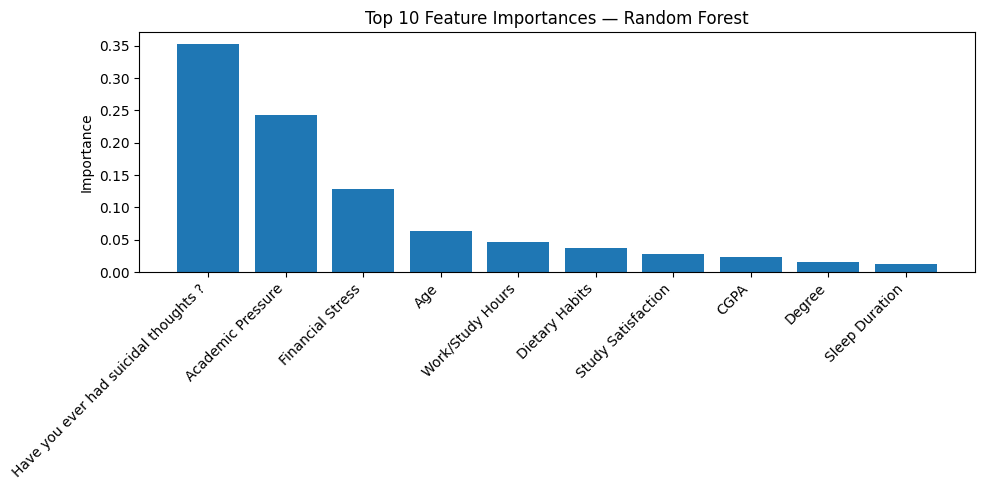

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(feature_importance_df["Feature"][:10],
        feature_importance_df["Importance"][:10])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Feature Importances — Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [30]:

kernels = ["linear", "rbf", "poly"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_kernel_results = []

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    scores = cross_val_score(svm, X_train, y_train, cv=cv, scoring="roc_auc")
    
    svm_kernel_results.append({
        "Kernel": kernel,
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

svm_kernel_df = pd.DataFrame(svm_kernel_results)
svm_kernel_df


,Kernel,Mean ROC-AUC,Std ROC-AUC
0,linear,0.921,0.001
1,rbf,0.920,0.001
2,poly,0.917,0.002


In [31]:
best_kernel = svm_kernel_df.loc[
    svm_kernel_df["Mean ROC-AUC"].idxmax(), "Kernel"
]

C_values = [0.1, 1, 10, 100]
svm_c_results = []

for C in C_values:
    svm = SVC(
        kernel=best_kernel,
        C=C,
        probability=True,
        random_state=42
    )
    scores = cross_val_score(svm, X_train, y_train, cv=cv, scoring="roc_auc")
    
    svm_c_results.append({
        "C": C,
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

svm_c_df = pd.DataFrame(svm_c_results)
svm_c_df


,C,Mean ROC-AUC,Std ROC-AUC
0,0.1,0.921,0.001
1,1.0,0.921,0.001
2,10.0,0.921,0.001
3,100.0,0.921,0.001


In [32]:
best_C = svm_c_df.loc[
    svm_c_df["Mean ROC-AUC"].idxmax(), "C"
]

svm_best = SVC(
    kernel=best_kernel,
    C=best_C,
    probability=True,
    random_state=42
)

start = perf_counter()
svm_best.fit(X_train, y_train)
svm_train_time = round(perf_counter() - start, 3)

best_kernel, best_C, svm_train_time


('linear', np.float64(0.1), 33.259)

In [33]:
y_pred_svm = svm_best.predict(X_test)
y_proba_svm = svm_best.predict_proba(X_test)[:, 1]

svm_metrics = {
    "Model": "SVM",
    "Accuracy": round(accuracy_score(y_test, y_pred_svm), 3),
    "Precision": round(precision_score(y_test, y_pred_svm), 3),
    "Recall": round(recall_score(y_test, y_pred_svm), 3),
    "F1": round(f1_score(y_test, y_pred_svm), 3),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba_svm), 3),
    "Training Time (s)": svm_train_time
}

svm_results_df = pd.DataFrame([svm_metrics])
svm_results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,SVM,0.849,0.858,0.889,0.873,0.922,33.259


In [34]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn, fp, fn, tp = cm_svm.ravel()

cm_svm_df = pd.DataFrame(
    cm_svm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

error_svm_df = pd.DataFrame({
    "Metric": [
        "True Positives (TP)",
        "False Positives (FP)",
        "True Negatives (TN)",
        "False Negatives (FN)"
    ],
    "Count": [tp, fp, tn, fn]
})

display(cm_svm_df)
display(error_svm_df)


,Predicted 0,Predicted 1
Actual 0,1832,479
Actual 1,363,2901


,Metric,Count
0,True Positives (TP),2901
1,False Positives (FP),479
2,True Negatives (TN),1832
3,False Negatives (FN),363


In [35]:
# Combine all model results
comparison_df = pd.concat([
    lr_results_df,
    dt_final_results_df,
    rf_results_df,
    svm_results_df
], ignore_index=True)

comparison_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.848,0.859,0.886,0.873,0.922,0.046
1,Decision Tree,0.833,0.836,0.888,0.861,0.901,0.047
2,Random Forest,0.844,0.846,0.897,0.871,0.919,1.705
3,SVM,0.849,0.858,0.889,0.873,0.922,33.259


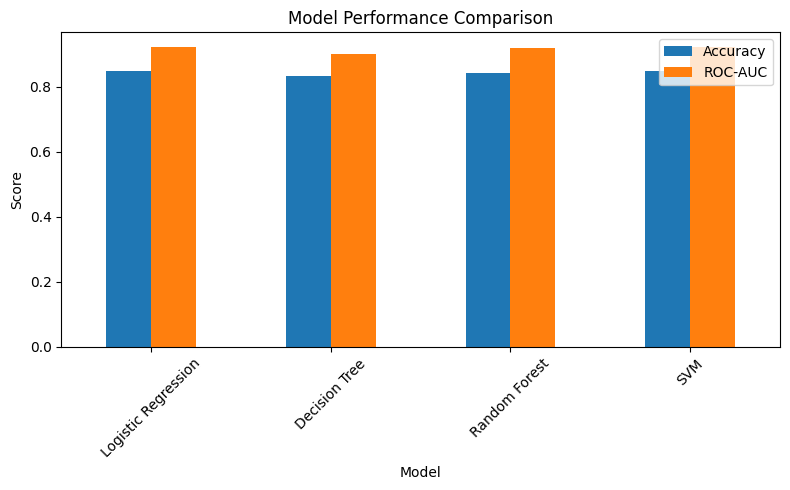

In [36]:
metrics_to_plot = ["Accuracy", "ROC-AUC"]

comparison_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


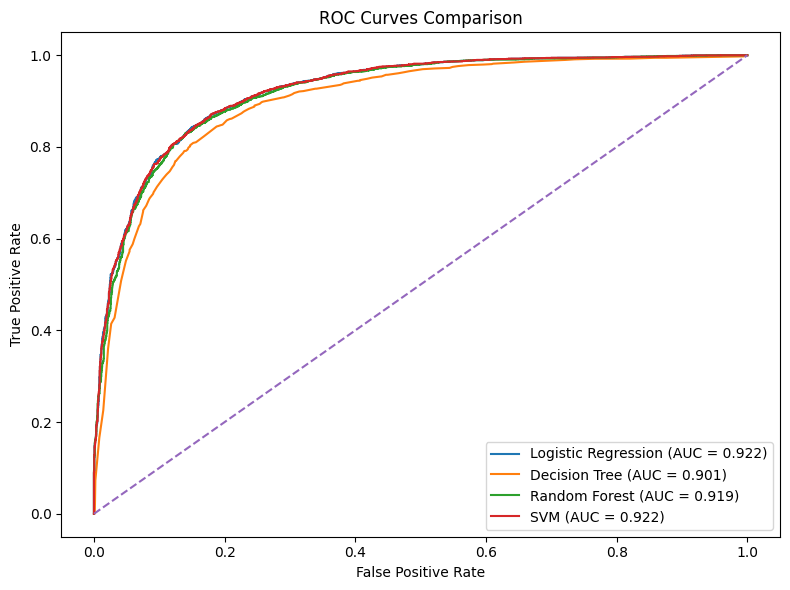

In [37]:
plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {comparison_df.loc[comparison_df.Model=='Logistic Regression','ROC-AUC'].values[0]:.3f})")

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt_final)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {comparison_df.loc[comparison_df.Model=='Decision Tree','ROC-AUC'].values[0]:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {comparison_df.loc[comparison_df.Model=='Random Forest','ROC-AUC'].values[0]:.3f})")

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {comparison_df.loc[comparison_df.Model=='SVM','ROC-AUC'].values[0]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_final,
    "Random Forest": rf_best,
    "SVM": svm_best
}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="roc_auc"
    )
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": round(scores.mean(), 3),
        "Std ROC-AUC": round(scores.std(), 3)
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df


,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.921,0.001
1,Decision Tree,0.900,0.002
2,Random Forest,0.917,0.002
3,SVM,0.921,0.001


In [39]:
# Create a list to store final test results
test_results = []

# List of models to evaluate on test data
final_models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_final,
    "Random Forest": rf_best,
    "SVM": svm_best
}

for name, model in final_models.items():
    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    test_results.append({
        "Model": name,
        "Test Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Test Precision": round(precision_score(y_test, y_pred), 3),
        "Test Recall": round(recall_score(y_test, y_pred), 3),
        "Test F1-Score": round(f1_score(y_test, y_pred), 3),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_proba), 3)
    })

# Display as a DataFrame
test_results_df = pd.DataFrame(test_results)
print("--- Final Model Performance on Test Data ---")
display(test_results_df)

--- Final Model Performance on Test Data ---


,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC
0,Logistic Regression,0.848,0.859,0.886,0.873,0.922
1,Decision Tree,0.833,0.836,0.888,0.861,0.901
2,Random Forest,0.844,0.846,0.897,0.871,0.919
3,SVM,0.849,0.858,0.889,0.873,0.922
